# 02 — Models & Performance
Εκπαίδευση και αξιολόγηση τριών μοντέλων: Logistic Regression (baseline),
XGBoost (κύριο μοντέλο) και Feed-Forward Neural Network (complexity benchmark).

## 1. Εισαγωγή βιβλιοθηκών

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, roc_curve, 
                             confusion_matrix, classification_report)
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow import keras
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print(f"TensorFlow version: {tf.__version__}")
print("Βιβλιοθήκες φορτώθηκαν επιτυχώς.")

TensorFlow version: 2.21.0
Βιβλιοθήκες φορτώθηκαν επιτυχώς.


## 2. Φόρτωση επεξεργασμένων δεδομένων

In [3]:
# Φόρτωση δεδομένων από το Milestone 1
DATA_DIR = '../data/processed'

X_train = np.load(f'{DATA_DIR}/X_train.npy')
X_val   = np.load(f'{DATA_DIR}/X_val.npy')
X_test  = np.load(f'{DATA_DIR}/X_test.npy')
y_train = np.load(f'{DATA_DIR}/y_train.npy')
y_val   = np.load(f'{DATA_DIR}/y_val.npy')
y_test  = np.load(f'{DATA_DIR}/y_test.npy')

X_train_scaled = np.load(f'{DATA_DIR}/X_train_scaled.npy')
X_val_scaled   = np.load(f'{DATA_DIR}/X_val_scaled.npy')
X_test_scaled  = np.load(f'{DATA_DIR}/X_test_scaled.npy')

feature_names = np.load(f'{DATA_DIR}/feature_names.npy', allow_pickle=True)

print(f"Train:      {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test:       {X_test.shape}")
print(f"Features:   {len(feature_names)}")

Train:      (6902, 23)
Validation: (1479, 23)
Test:       (1480, 23)
Features:   23


## 3. Συνάρτηση Αξιολόγησης
Ορισμός κοινής συνάρτησης για AUC-ROC, Gini, KS Statistic και Accuracy.

In [4]:
def evaluate_model(model_name, y_true, y_prob, y_pred):
    auc = roc_auc_score(y_true, y_prob)
    gini = 2 * auc - 1
    
    # KS statistic — max gap μεταξύ TPR και FPR, ισοδύναμο της ks_2samp
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ks = (tpr - fpr).max()
    
    acc = (y_true == y_pred).mean()
    
    print(f"{'='*40}")
    print(f"  {model_name}")
    print(f"{'='*40}")
    print(f"  AUC-ROC:  {auc:.4f}")
    print(f"  Gini:     {gini:.4f}")
    print(f"  KS Stat:  {ks:.4f}")
    print(f"  Accuracy: {acc:.4f}")
    print(f"{'='*40}")
    
    return {'model': model_name, 'AUC': auc, 
            'Gini': gini, 'KS': ks, 'Accuracy': acc}

print("Συνάρτηση αξιολόγησης ορίστηκε.")

Συνάρτηση αξιολόγησης ορίστηκε.


## 4. Logistic Regression (Baseline)

In [5]:
# Εκπαίδευση
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Προβλέψεις
lr_prob_val  = lr_model.predict_proba(X_val_scaled)[:, 1]
lr_pred_val  = lr_model.predict(X_val_scaled)
lr_prob_test = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_pred_test = lr_model.predict(X_test_scaled)

# Αξιολόγηση
print("--- Validation Set ---")
lr_val_scores = evaluate_model("Logistic Regression", y_val, lr_prob_val, lr_pred_val)
print()
print("--- Test Set ---")
lr_test_scores = evaluate_model("Logistic Regression", y_test, lr_prob_test, lr_pred_test)

--- Validation Set ---
  Logistic Regression
  AUC-ROC:  0.7914
  Gini:     0.5828
  KS Stat:  0.4655
  Accuracy: 0.7302

--- Test Set ---
  Logistic Regression
  AUC-ROC:  0.7894
  Gini:     0.5787
  KS Stat:  0.4554
  Accuracy: 0.7209


In [6]:
# Overfitting check
lr_prob_train = lr_model.predict_proba(X_train_scaled)[:, 1]
lr_pred_train = lr_model.predict(X_train_scaled)
auc_train = roc_auc_score(y_train, lr_prob_train)
auc_val   = roc_auc_score(y_val, lr_prob_val)

print("Overfitting Check — Logistic Regression")
print(f"  AUC Train:      {auc_train:.4f}")
print(f"  AUC Validation: {auc_val:.4f}")
print(f"  Διαφορά:        {auc_train - auc_val:.4f}")
if auc_train - auc_val < 0.02:
    print("  → Κανένα σημάδι overfitting")
else:
    print("  → Πιθανό overfitting")

Overfitting Check — Logistic Regression
  AUC Train:      0.8019
  AUC Validation: 0.7914
  Διαφορά:        0.0105
  → Κανένα σημάδι overfitting


## 5. XGBoost

In [7]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,          # subsample + colsample_bytree εισάγουν τυχαιότητα → μειώνουν overfitting
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=20,
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f"Best iteration: {xgb_model.best_iteration}")

Best iteration: 140


In [8]:
# Προβλέψεις
xgb_prob_val  = xgb_model.predict_proba(X_val)[:, 1]
xgb_pred_val  = xgb_model.predict(X_val)
xgb_prob_test = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred_test = xgb_model.predict(X_test)

# Αξιολόγηση
print("--- Validation Set ---")
xgb_val_scores = evaluate_model("XGBoost", y_val, xgb_prob_val, xgb_pred_val)
print()
print("--- Test Set ---")
xgb_test_scores = evaluate_model("XGBoost", y_test, xgb_prob_test, xgb_pred_test)

--- Validation Set ---
  XGBoost
  AUC-ROC:  0.8061
  Gini:     0.6121
  KS Stat:  0.4922
  Accuracy: 0.7431

--- Test Set ---
  XGBoost
  AUC-ROC:  0.7963
  Gini:     0.5927
  KS Stat:  0.4577
  Accuracy: 0.7243


In [9]:
# Overfitting check
xgb_prob_train = xgb_model.predict_proba(X_train)[:, 1]
auc_train = roc_auc_score(y_train, xgb_prob_train)
auc_val   = roc_auc_score(y_val, xgb_prob_val)

print("Overfitting Check — XGBoost")
print(f"  AUC Train:      {auc_train:.4f}")
print(f"  AUC Validation: {auc_val:.4f}")
print(f"  Διαφορά:        {auc_train - auc_val:.4f}")
if auc_train - auc_val < 0.02:
    print("  → Κανένα σημάδι overfitting")
else:
    print("  → Πιθανό overfitting")

Overfitting Check — XGBoost
  AUC Train:      0.8589
  AUC Validation: 0.8061
  Διαφορά:        0.0529
  → Πιθανό overfitting


## 6. Feed-Forward Neural Network (Complexity Benchmark)

In [10]:
tf.random.set_seed(42)

ffnn_model = keras.Sequential([
    keras.layers.Input(shape=(23,)),  # 23 input features — 64→32 εκτιμήθηκε αρκετό
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
])

ffnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['AUC']
)

ffnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,649 (14.25 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_AUC',
    patience=15,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

history = ffnn_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nΕκπαίδευση ολοκληρώθηκε.")
print(f"Epochs που έτρεξαν: {len(history.history['loss'])}")

Epoch 1/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.7395 - loss: 0.6029 - val_AUC: 0.7949 - val_loss: 0.5521
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.7765 - loss: 0.5725 - val_AUC: 0.7955 - val_loss: 0.5515
Epoch 3/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.7899 - loss: 0.5563 - val_AUC: 0.7956 - val_loss: 0.5521
Epoch 4/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.7919 - loss: 0.5547 - val_AUC: 0.7961 - val_loss: 0.5521
Epoch 5/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.7933 - loss: 0.5539 - val_AUC: 0.7947 - val_loss: 0.5539
Epoch 6/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.7987 - loss: 0.5479 - val_AUC: 0.7962 - val_loss: 0.5522
Epoch 7/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.7967 - loss: 0.5502 - val_AUC: 0.7966 - val_loss: 0.5528
Epoch 8/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.8009 - loss: 0.5433 - val_AUC: 0.7967 - val_loss: 0.5541
Epoch 9/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/

In [12]:
# Προβλέψεις
ffnn_prob_val  = ffnn_model.predict(X_val_scaled, verbose=0).flatten()
ffnn_pred_val  = (ffnn_prob_val >= 0.5).astype(int)
ffnn_prob_test = ffnn_model.predict(X_test_scaled, verbose=0).flatten()
ffnn_pred_test = (ffnn_prob_test >= 0.5).astype(int)

# Αξιολόγηση
print("--- Validation Set ---")
ffnn_val_scores = evaluate_model("FFNN", y_val, ffnn_prob_val, ffnn_pred_val)
print()
print("--- Test Set ---")
ffnn_test_scores = evaluate_model("FFNN", y_test, ffnn_prob_test, ffnn_pred_test)

--- Validation Set ---
  FFNN
  AUC-ROC:  0.7975
  Gini:     0.5951
  KS Stat:  0.4897
  Accuracy: 0.7424

--- Test Set ---
  FFNN
  AUC-ROC:  0.7934
  Gini:     0.5869
  KS Stat:  0.4648
  Accuracy: 0.7189


In [13]:
# Overfitting check
ffnn_prob_train = ffnn_model.predict(X_train_scaled, verbose=0).flatten()
auc_train = roc_auc_score(y_train, ffnn_prob_train)
auc_val   = roc_auc_score(y_val, ffnn_prob_val)

print("Overfitting Check — FFNN")
print(f"  AUC Train:      {auc_train:.4f}")
print(f"  AUC Validation: {auc_val:.4f}")
print(f"  Διαφορά:        {auc_train - auc_val:.4f}")
if auc_train - auc_val < 0.02:
    print("  → Κανένα σημάδι overfitting")
else:
    print("  → Πιθανό overfitting")

Overfitting Check — FFNN
  AUC Train:      0.8188
  AUC Validation: 0.7975
  Διαφορά:        0.0212
  → Πιθανό overfitting


## 7. Σύγκριση Μοντέλων

                        AUC    Gini      KS  Accuracy
model                                                
Logistic Regression  0.7894  0.5787  0.4554    0.7209
XGBoost              0.7963  0.5927  0.4577    0.7243
FFNN                 0.7934  0.5869  0.4648    0.7189


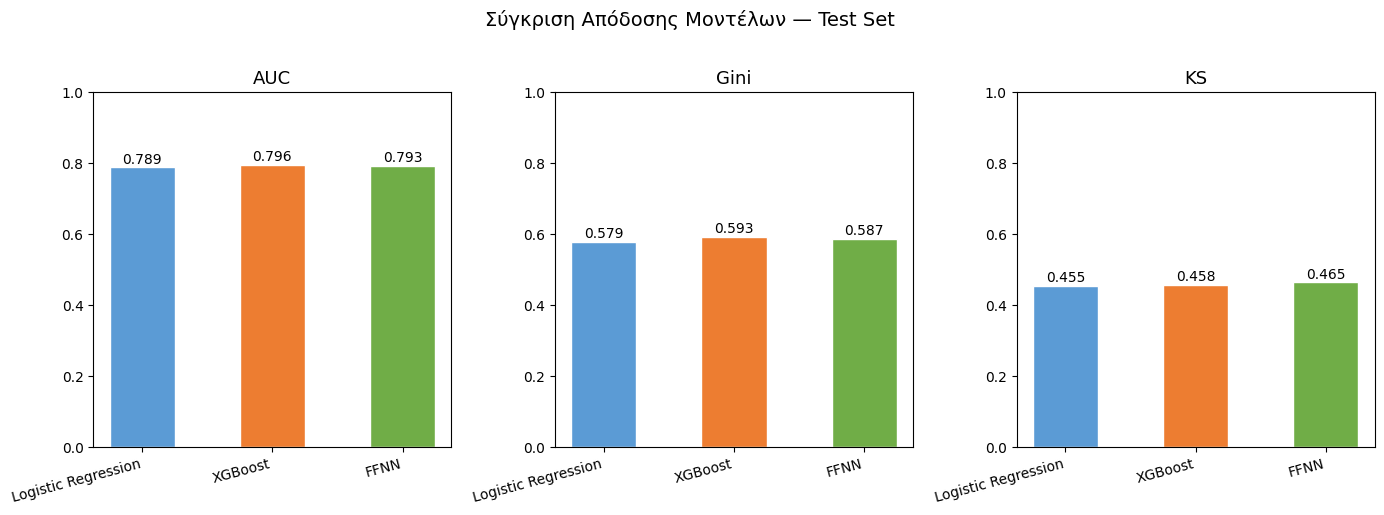

Αποθηκεύτηκε: figures/04_model_comparison.png


In [14]:
# Συγκριτικός πίνακας
results = pd.DataFrame([lr_test_scores, xgb_test_scores, ffnn_test_scores])
results = results.set_index('model')
print(results.round(4))

# Γράφημα σύγκρισης
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['AUC', 'Gini', 'KS']
colors = ['#5b9bd5', '#ed7d31', '#70ad47']

for i, metric in enumerate(metrics):
    bars = axes[i].bar(results.index, results[metric], 
                       color=colors, edgecolor='white', width=0.5)
    axes[i].set_title(metric, fontsize=13)
    axes[i].set_ylim(0, 1)
    axes[i].set_xticklabels(results.index, rotation=15, ha='right')
    for bar, val in zip(bars, results[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2, 
                    bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', fontsize=10)

plt.suptitle('Σύγκριση Απόδοσης Μοντέλων — Test Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/04_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Αποθηκεύτηκε: figures/04_model_comparison.png")

## 8. ROC Curves — Σύγκριση Μοντέλων

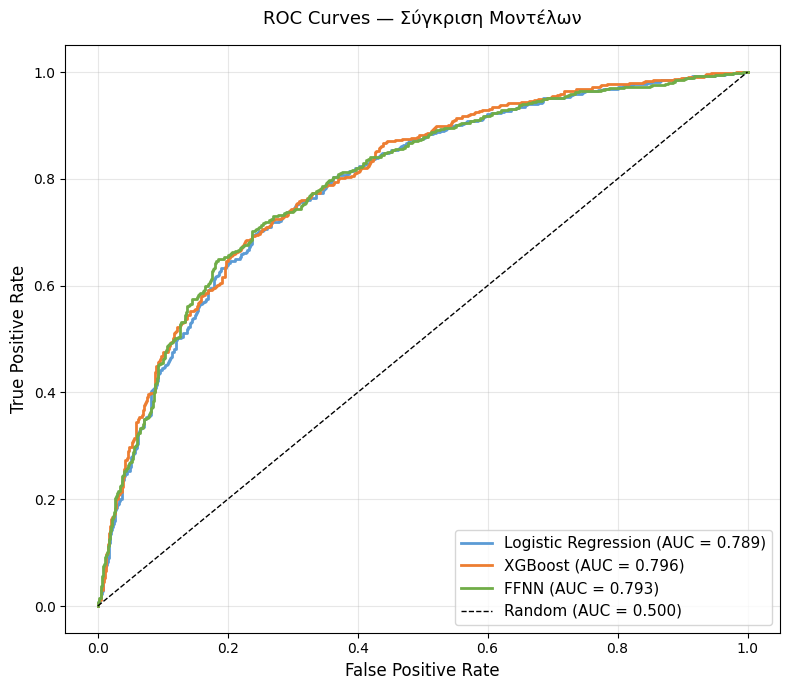

Αποθηκεύτηκε: figures/14_roc_curves.png


In [15]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 7))

# ROC για κάθε μοντέλο
models_data = [
    ('Logistic Regression', lr_prob_test, '#5b9bd5'),
    ('XGBoost', xgb_prob_test, '#ed7d31'),
    ('FFNN', ffnn_prob_test, '#70ad47')
]

for name, prob, color in models_data:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Σύγκριση Μοντέλων', fontsize=13, pad=15)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/14_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Αποθηκεύτηκε: figures/14_roc_curves.png")

## 9. Confusion Matrix — Επιχειρηματικός Αντίκτυπος

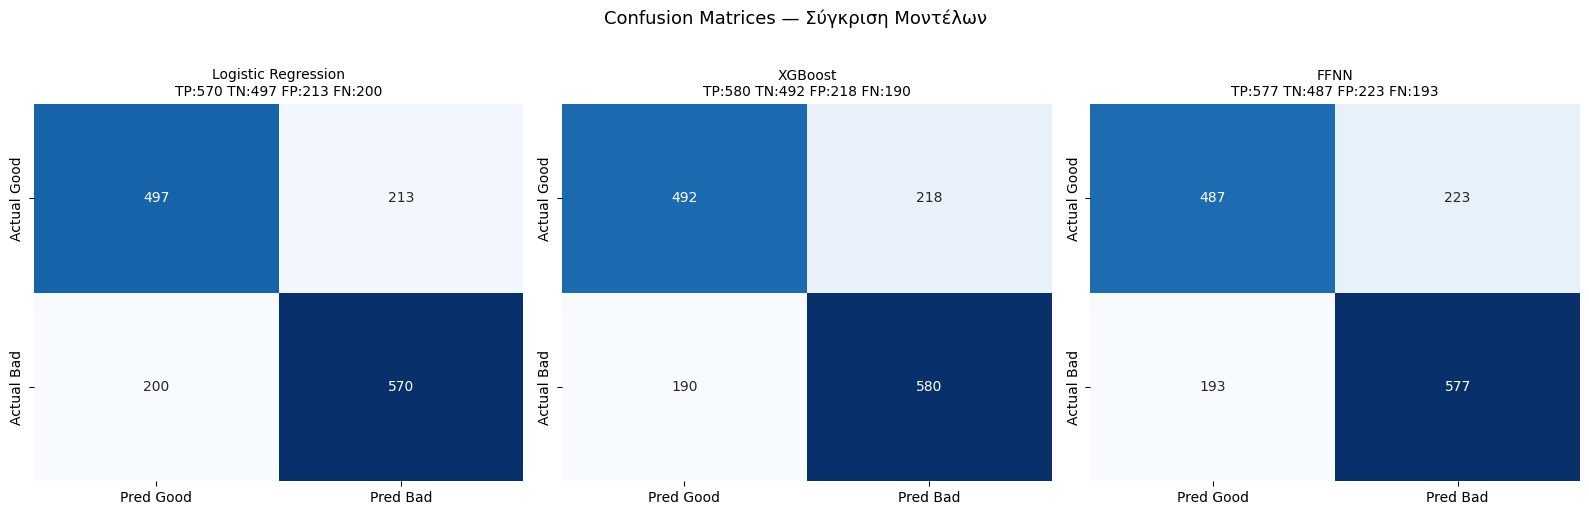

Αποθηκεύτηκε: figures/15_confusion_matrices.png


In [16]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_preds = [
    ('Logistic Regression', lr_pred_test),
    ('XGBoost', xgb_pred_test),
    ('FFNN', ffnn_pred_test)
]

for i, (name, pred) in enumerate(models_preds):
    cm = confusion_matrix(y_test, pred)
    
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Pred Good', 'Pred Bad'],
        yticklabels=['Actual Good', 'Actual Bad'],
        ax=axes[i], cbar=False
    )
    
    tn, fp, fn, tp = cm.ravel()
    axes[i].set_title(
        f'{name}\nTP:{tp} TN:{tn} FP:{fp} FN:{fn}', 
        fontsize=10
    )

plt.suptitle('Confusion Matrices — Σύγκριση Μοντέλων', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/15_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Αποθηκεύτηκε: figures/15_confusion_matrices.png")

## 10. Threshold Analysis
Επίδραση του threshold στις μετρικές αξιολόγησης.
Το default threshold είναι 0.5 αλλά η τράπεζα μπορεί να επιλέξει διαφορετικό
ανάλογα με τη στρατηγική της.

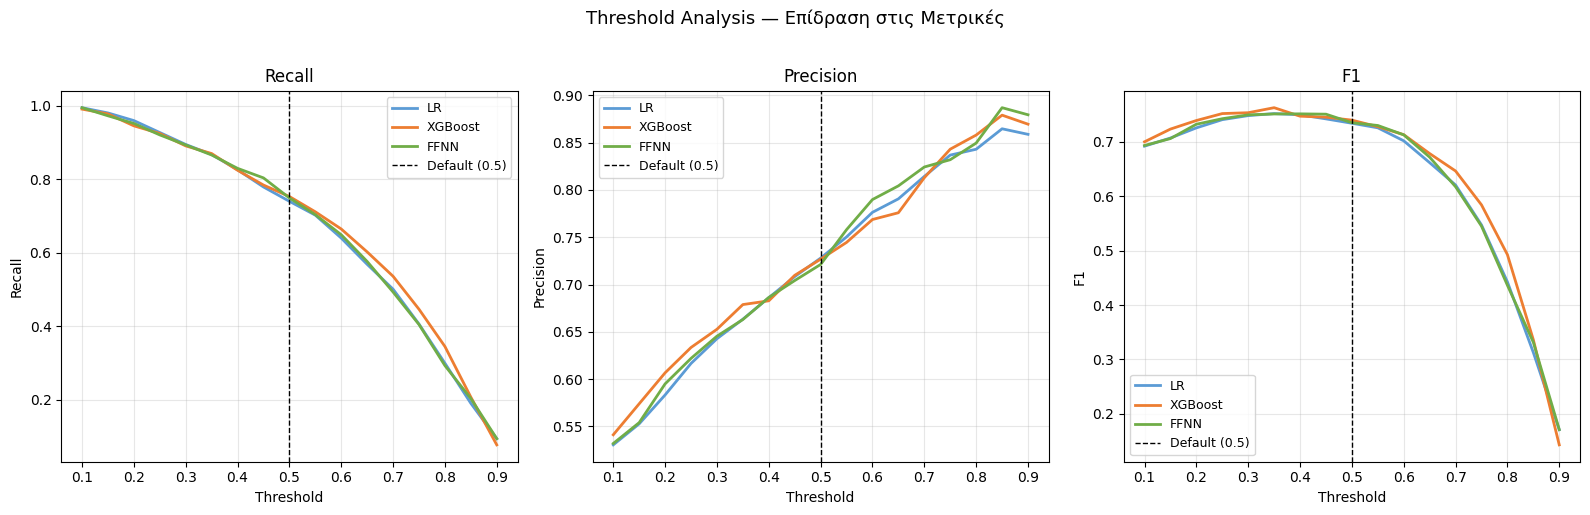

Αποθηκεύτηκε: figures/18_threshold_analysis.png


In [17]:
thresholds = np.arange(0.1, 0.91, 0.05)

results_threshold = []
for thresh in thresholds:
    for name, prob in [('LR', lr_prob_test), 
                       ('XGBoost', xgb_prob_test), 
                       ('FFNN', ffnn_prob_test)]:
        pred = (prob >= thresh).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        fpr       = fp / (fp + tn) if (fp + tn) > 0 else 0
        
        results_threshold.append({
            'Model': name, 'Threshold': thresh,
            'Precision': precision, 'Recall': recall,
            'F1': f1, 'FPR': fpr
        })

thresh_df = pd.DataFrame(results_threshold)

# Γράφημα
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = {'LR': '#5b9bd5', 'XGBoost': '#ed7d31', 'FFNN': '#70ad47'}

for ax, metric in zip(axes, ['Recall', 'Precision', 'F1']):
    for model, color in colors.items():
        data = thresh_df[thresh_df['Model'] == model]
        ax.plot(data['Threshold'], data[metric], 
                color=color, linewidth=2, label=model)
    ax.axvline(x=0.5, color='black', linestyle='--', 
               linewidth=1, label='Default (0.5)')
    ax.set_title(metric, fontsize=12)
    ax.set_xlabel('Threshold', fontsize=10)
    ax.set_ylabel(metric, fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Threshold Analysis — Επίδραση στις Μετρικές', 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/18_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Αποθηκεύτηκε: figures/18_threshold_analysis.png")

## 11. Decile Analysis
Χωρισμός δανειοληπτών σε 10 ομάδες βάσει score.
Κλασική ανάλυση στον credit scoring — δείχνει πόσο καλά
διαχωρίζει το μοντέλο τους Bad από τους Good.

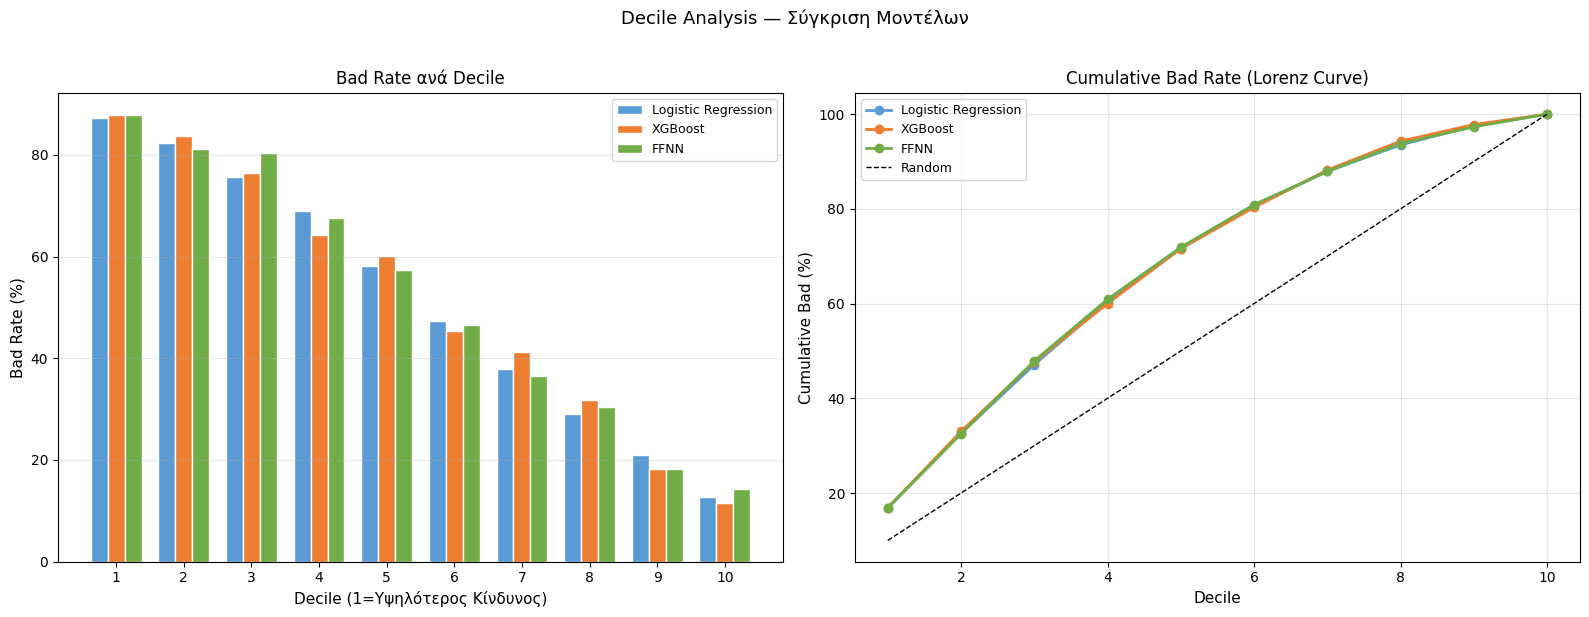

Αποθηκεύτηκε: figures/19_decile_analysis.png


In [18]:
def decile_analysis(y_true, y_prob, model_name):
    df = pd.DataFrame({'prob': y_prob, 'actual': y_true})
    df = df.sort_values('prob', ascending=False).reset_index(drop=True)
    df['decile'] = pd.qcut(df.index, 10, labels=range(1, 11))
    
    decile_df = df.groupby('decile', observed=True).agg(
        Total=('actual', 'count'),
        Bad=('actual', 'sum')
    ).reset_index()
    
    decile_df['Good'] = decile_df['Total'] - decile_df['Bad']
    decile_df['Bad_Rate'] = (decile_df['Bad'] / decile_df['Total'] * 100).round(1)
    decile_df['Cum_Bad_Pct'] = (decile_df['Bad'].cumsum() / decile_df['Bad'].sum() * 100).round(1)
    decile_df['Model'] = model_name
    
    return decile_df

lr_decile   = decile_analysis(y_test, lr_prob_test, 'Logistic Regression')
xgb_decile  = decile_analysis(y_test, xgb_prob_test, 'XGBoost')
ffnn_decile = decile_analysis(y_test, ffnn_prob_test, 'FFNN')

# Γράφημα Bad Rate ανά decile
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = {'Logistic Regression': '#5b9bd5', 
          'XGBoost': '#ed7d31', 
          'FFNN': '#70ad47'}

x = np.arange(1, 11)
width = 0.25

for i, (df, name) in enumerate([(lr_decile, 'Logistic Regression'),
                                  (xgb_decile, 'XGBoost'),
                                  (ffnn_decile, 'FFNN')]):
    axes[0].bar(x + (i-1)*width, df['Bad_Rate'], width,
                label=name, color=colors[name], edgecolor='white')

axes[0].set_xlabel('Decile (1=Υψηλότερος Κίνδυνος)', fontsize=11)
axes[0].set_ylabel('Bad Rate (%)', fontsize=11)
axes[0].set_title('Bad Rate ανά Decile', fontsize=12)
axes[0].set_xticks(x)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, axis='y')

# Cumulative Bad Rate
for df, name, color in [(lr_decile, 'Logistic Regression', '#5b9bd5'),
                         (xgb_decile, 'XGBoost', '#ed7d31'),
                         (ffnn_decile, 'FFNN', '#70ad47')]:
    axes[1].plot(df['decile'].astype(int), df['Cum_Bad_Pct'],
                marker='o', color=color, linewidth=2, label=name)

axes[1].plot([1, 10], [10, 100], 'k--', linewidth=1, label='Random')
axes[1].set_xlabel('Decile', fontsize=11)
axes[1].set_ylabel('Cumulative Bad (%)', fontsize=11)
axes[1].set_title('Cumulative Bad Rate (Lorenz Curve)', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Decile Analysis — Σύγκριση Μοντέλων', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/19_decile_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Αποθηκεύτηκε: figures/19_decile_analysis.png")

## 12. Calibration Plot
Έλεγχος αξιοπιστίας των probabilities — αν το μοντέλο λέει
"70% πιθανότητα Bad", όντως το 70% αυτών είναι Bad;

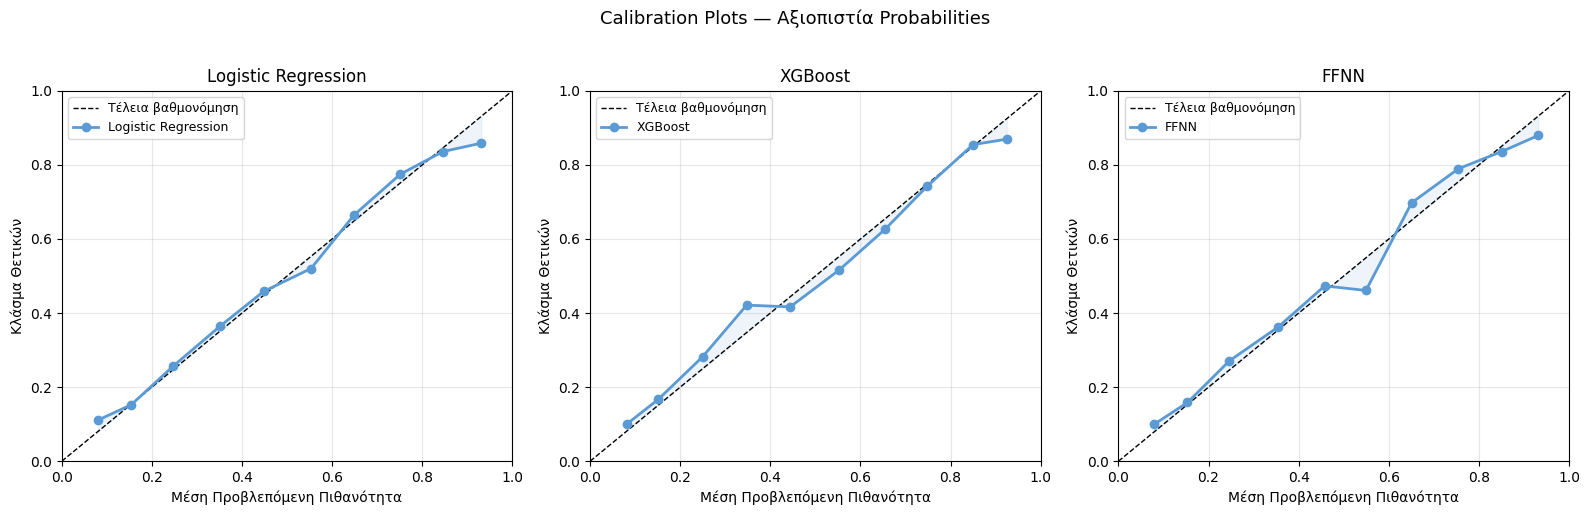

Αποθηκεύτηκε: figures/22_calibration.png


In [19]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_cal = [
    ('Logistic Regression', lr_prob_test),
    ('XGBoost', xgb_prob_test),
    ('FFNN', ffnn_prob_test)
]

for i, (name, prob) in enumerate(models_cal):
    fraction_pos, mean_pred = calibration_curve(
        y_test, prob, n_bins=10, strategy='uniform'
    )
    
    axes[i].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Τέλεια βαθμονόμηση')
    axes[i].plot(mean_pred, fraction_pos, 
                marker='o', linewidth=2, 
                color='#5b9bd5', label=name)
    axes[i].fill_between(mean_pred, fraction_pos, mean_pred,
                         alpha=0.1, color='#5b9bd5')
    axes[i].set_xlabel('Μέση Προβλεπόμενη Πιθανότητα', fontsize=10)
    axes[i].set_ylabel('Κλάσμα Θετικών', fontsize=10)
    axes[i].set_title(name, fontsize=12)
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)

plt.suptitle('Calibration Plots — Αξιοπιστία Probabilities', 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/22_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print("Αποθηκεύτηκε: figures/22_calibration.png")

## 13. Συγκεντρωτικός Πίνακας Αξιολόγησης

            Μοντέλο  AUC-ROC  Gini    KS  Disparate Impact  PSI (train→test)
Logistic Regression    0.789 0.579 0.455             0.471             0.003
            XGBoost    0.796 0.593 0.458             0.474             0.003
               FFNN    0.793 0.587 0.465             0.466             0.005


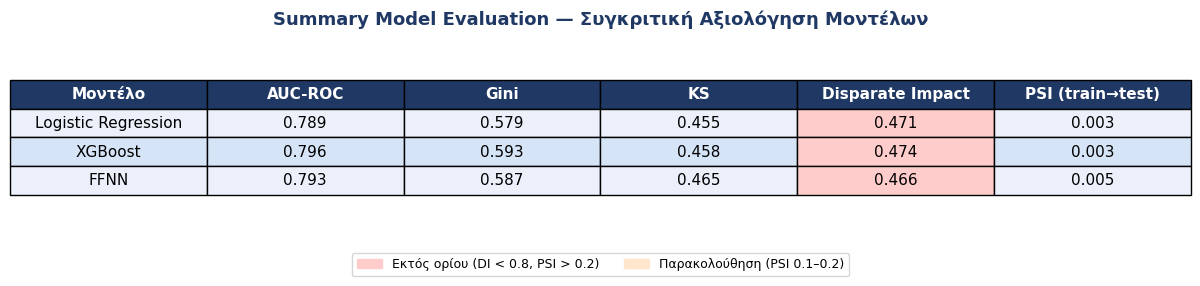

Αποθηκεύτηκε: figures/23_summary_table.png


In [25]:
import matplotlib.patches as mpatches
from scipy import stats

# Sensitive feature για τον πίνακα
avg_m_idx_test = list(feature_names).index('AverageMInFile')
median_test = np.median(X_test[:, avg_m_idx_test])
sensitive_test = (X_test[:, avg_m_idx_test] >= median_test).astype(int)

def disparate_impact_ratio(y_pred, sensitive):
    r0 = (y_pred[sensitive == 0] == 0).mean()
    r1 = (y_pred[sensitive == 1] == 0).mean()
    return min(r0, r1) / max(r0, r1)

def ks_stat(y_true, y_prob):
    pos = y_prob[y_true == 1]
    neg = y_prob[y_true == 0]
    return stats.ks_2samp(pos, neg).statistic

def calculate_psi_summary(expected, actual, bins=10):
    breakpoints = np.linspace(0, 1, bins + 1)
    def bucket(arr):
        counts, _ = np.histogram(arr, bins=breakpoints)
        pct = counts / len(arr)
        pct = np.where(pct == 0, 1e-6, pct)  # floor για αποφυγή log(0) στον υπολογισμό PSI
        return pct
    e, a = bucket(expected), bucket(actual)
    return np.sum((a - e) * np.log(a / e))

# Probabilities train set για PSI
lr_prob_train_s   = lr_model.predict_proba(X_train_scaled)[:, 1]
xgb_prob_train_s  = xgb_model.predict_proba(X_train)[:, 1]
ffnn_prob_train_s = ffnn_model.predict(X_train_scaled, verbose=0).flatten()

results_summary = {
    'Μοντέλο': ['Logistic Regression', 'XGBoost', 'FFNN'],
    'AUC-ROC': [
        round(roc_auc_score(y_test, lr_prob_test),   3),
        round(roc_auc_score(y_test, xgb_prob_test),  3),
        round(roc_auc_score(y_test, ffnn_prob_test), 3),
    ],
    'Gini': [
        round(2*roc_auc_score(y_test, lr_prob_test)-1,   3),
        round(2*roc_auc_score(y_test, xgb_prob_test)-1,  3),
        round(2*roc_auc_score(y_test, ffnn_prob_test)-1, 3),
    ],
    'KS': [
        round(ks_stat(y_test, lr_prob_test),   3),
        round(ks_stat(y_test, xgb_prob_test),  3),
        round(ks_stat(y_test, ffnn_prob_test), 3),
    ],
    'Disparate Impact': [
        round(disparate_impact_ratio(lr_pred_test,   sensitive_test), 3),
        round(disparate_impact_ratio(xgb_pred_test,  sensitive_test), 3),
        round(disparate_impact_ratio(ffnn_pred_test, sensitive_test), 3),
    ],
    'PSI (train→test)': [
        round(calculate_psi_summary(lr_prob_train_s,   lr_prob_test),   3),
        round(calculate_psi_summary(xgb_prob_train_s,  xgb_prob_test),  3),
        round(calculate_psi_summary(ffnn_prob_train_s, ffnn_prob_test), 3),
    ],
}

df_summary = pd.DataFrame(results_summary)
print(df_summary.to_string(index=False))

# Οπτικοποίηση
fig, ax = plt.subplots(figsize=(12, 2.5))
ax.axis('off')

table = ax.table(
    cellText=df_summary.values,
    colLabels=df_summary.columns,
    cellLoc='center',
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

for j in range(len(df_summary.columns)):
    table[0, j].set_facecolor('#1F3864')
    table[0, j].set_text_props(color='white', fontweight='bold')

row_colors = ['#EBF0FA', '#D6E4F7', '#EBF0FA']
for i, color in enumerate(row_colors, start=1):
    for j in range(len(df_summary.columns)):
        table[i, j].set_facecolor(color)

di_col  = list(df_summary.columns).index('Disparate Impact')
psi_col = list(df_summary.columns).index('PSI (train→test)')

for i in range(1, 4):
    di_val  = float(df_summary.iloc[i-1]['Disparate Impact'])
    psi_val = float(df_summary.iloc[i-1]['PSI (train→test)'])
    if di_val < 0.8:
        table[i, di_col].set_facecolor('#FFCCCC')
    if psi_val > 0.2:
        table[i, psi_col].set_facecolor('#FFCCCC')
    elif psi_val > 0.1:
        table[i, psi_col].set_facecolor('#FFE5CC')

red_patch    = mpatches.Patch(color='#FFCCCC', label='Εκτός ορίου (DI < 0.8, PSI > 0.2)')
orange_patch = mpatches.Patch(color='#FFE5CC', label='Παρακολούθηση (PSI 0.1–0.2)')
fig.legend(handles=[red_patch, orange_patch], 
           loc='lower center', 
           ncol=2,
           fontsize=9,
           bbox_to_anchor=(0.5, -0.15))

plt.title('Summary Model Evaluation — Συγκριτική Αξιολόγηση Μοντέλων', 
          fontsize=13, fontweight='bold', color='#1F3864', pad=15)
plt.tight_layout()
plt.savefig('../figures/23_summary_table.png', dpi=150, bbox_inches='tight')
plt.show()
print("Αποθηκεύτηκε: figures/23_summary_table.png")